# EDA

In [3]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, InputLayer, Conv1D, MaxPooling1D, Flatten, Dropout, LSTM, Dropout, LSTM
from sklearn.metrics import mean_squared_error

In [4]:
datasets = {'AAPL': 'AAPL.csv', 'MSFT': 'MSFT.csv', 'NVDA': 'NVDA.csv'}

all_data = []
for company, file_name in datasets.items():
  df = pd.read_csv(file_name)
  df['Company'] = company # Add a column to identify the company
  all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)


In [5]:
# Show some first data samples
companies = ['AAPL', 'MSFT', 'NVDA']
combined_df.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close,Company
0,12-12-1980,0.128348,0.128348,469033600,0.128906,0.128348,0.099874,AAPL
1,15-12-1980,0.121652,0.122210,175884800,0.122210,0.121652,0.094663,AAPL
2,16-12-1980,0.112723,0.113281,105728000,0.113281,0.112723,0.087715,AAPL
3,17-12-1980,0.115513,0.115513,86441600,0.116071,0.115513,0.089886,AAPL
4,18-12-1980,0.118862,0.118862,73449600,0.119420,0.118862,0.092492,AAPL


In [6]:
# Get some info about the data
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25867 entries, 0 to 25866
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            25867 non-null  object 
 1   Low             25867 non-null  float64
 2   Open            25867 non-null  float64
 3   Volume          25867 non-null  int64  
 4   High            25867 non-null  float64
 5   Close           25867 non-null  float64
 6   Adjusted Close  25867 non-null  float64
 7   Company         25867 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.6+ MB


In [7]:
def data_split_label(dataset, feature_columns, predicted_label, window_size, k, consecutive=False):
  ### Split the dataset into time windows to get data samples.

  df=dataset
  X_data = []
  y_data = []

  # Get the indices of feature columns
  feature_indices = [df.columns.get_loc(col) for col in feature_columns]
  num_features = len(feature_columns) # Store the number of features

  # The label will be the predicted_label's price of the 7th day after the window
  label_index = df.columns.get_loc(predicted_label)
  # Predict 7 days into the future

  for i in range(0, len(df) - window_size - k + 1):
      data_feature = []
      # Get a window_size time frame for data features
      for j in range(window_size):
          # Ensure all features are float32
          data_feature.append(df.iloc[i + j, feature_indices].values.astype(np.float32))

      # Append new data sample (feature and label) to X_data and y_data
      X_data.append(np.array(data_feature)) # Each element in X_data is (window_size, num_features)

      if consecutive:
          # Get k consecutive labels starting from `i + window_size`
          labels_for_window = df.iloc[i + window_size : i + window_size + k, label_index].values.astype(np.float32)
          y_data.append(labels_for_window) # Append array of k labels
      else:
          # Label is the price k after the window ends
          data_label = df.iloc[i + window_size + k - 1, label_index].astype(np.float32)
          y_data.append(np.array([data_label])) # Each element in y_data is (1,) to match model output

  print(f"Number of features used: {num_features}")
  return X_data, y_data, num_features

In [8]:
from sklearn.model_selection import train_test_split as sk_train_test_split
def prepare_train_val_test_data(X_data, y_data, window_size, num_features, num_prediction_steps):
  X_train, X_test, y_train, y_test = sk_train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
  X_train, X_val, y_train, y_val = sk_train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

  # Convert from lists to Numpy arrays for reshaping purpose
  X_train = np.array(X_train)
  X_val = np.array(X_val)
  X_test = np.array(X_test)
  y_train = np.array(y_train)
  y_val = np.array(y_val)
  y_test = np.array(y_test)

  # Reshape the numpy array to fit the neural network input shape requirement
  X_train = X_train.reshape(X_train.shape[0], window_size, num_features)
  X_val = X_val.reshape(X_val.shape[0], window_size, num_features)
  X_test = X_test.reshape(X_test.shape[0], window_size, num_features)

  # Reshape y arrays to (num_samples, num_prediction_steps)
  if y_train.ndim == 1: # If it's (N,) make it (N, 1)
      y_train = y_train.reshape(-1, 1)
      y_val = y_val.reshape(-1, 1)
      y_test = y_test.reshape(-1, 1)

  # Ensure y arrays have the correct second dimension for multiple prediction steps
  if num_prediction_steps > 1 and y_train.shape[1] != num_prediction_steps:
      y_train = y_train.reshape(-1, num_prediction_steps)
      y_val = y_val.reshape(-1, num_prediction_steps)
      y_test = y_test.reshape(-1, num_prediction_steps)

  # Print shape of the training, validation and test set
  print("Shape of training set: ", X_train.shape)
  print("Shape of validation set: ", X_val.shape)
  print("Shape of test set: ", X_test.shape)
  print("Shape of training set labels: ", y_train.shape)
  print("Shape of validation set labels: ", y_val.shape)
  print("Shape of test set labels: ", y_test.shape)

  return X_train, X_val, X_test, y_train, y_val, y_test


Number of features used: 6
Shape of training set:  (6772, 7, 6)
Shape of validation set:  (1694, 7, 6)
Shape of test set:  (2117, 7, 6)
Shape of training set labels:  (6772, 1)
Shape of validation set labels:  (1694, 1)
Shape of test set labels:  (2117, 1)


<Figure size 1200x600 with 0 Axes>

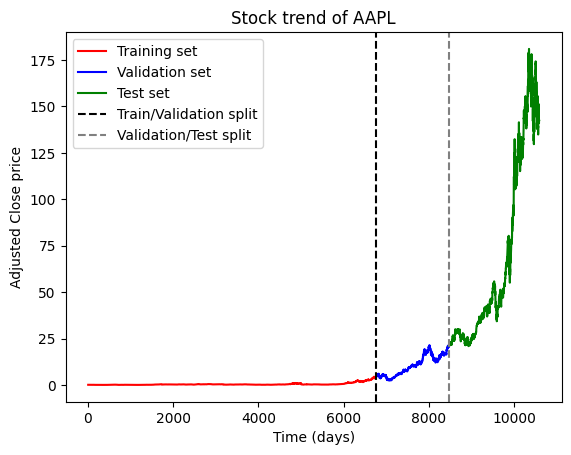

Number of features used: 6
Shape of training set:  (5924, 7, 6)
Shape of validation set:  (1481, 7, 6)
Shape of test set:  (1852, 7, 6)
Shape of training set labels:  (5924, 1)
Shape of validation set labels:  (1481, 1)
Shape of test set labels:  (1852, 1)


<Figure size 1200x600 with 0 Axes>

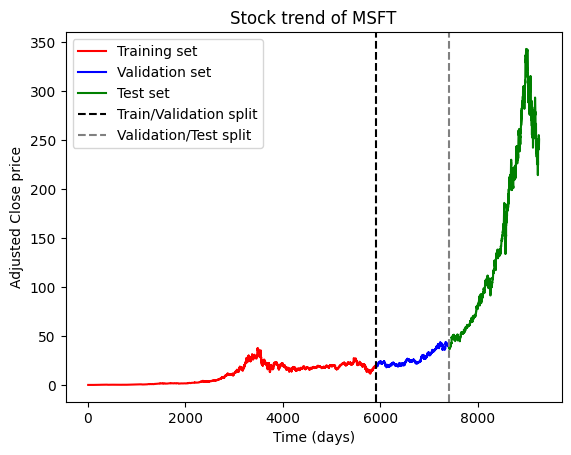

Number of features used: 6
Shape of training set:  (3843, 7, 6)
Shape of validation set:  (961, 7, 6)
Shape of test set:  (1202, 7, 6)
Shape of training set labels:  (3843, 1)
Shape of validation set labels:  (961, 1)
Shape of test set labels:  (1202, 1)


<Figure size 1200x600 with 0 Axes>

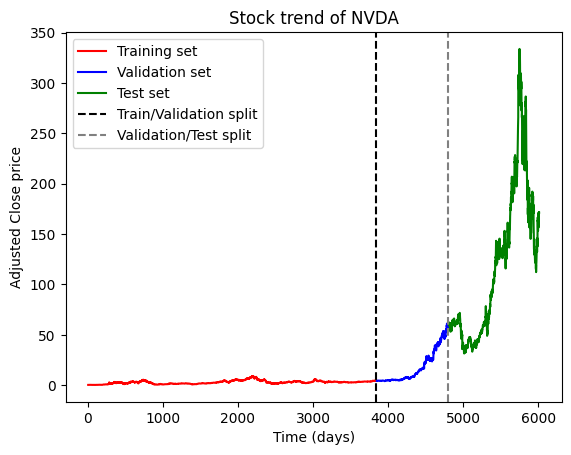

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define parameters for data splitting
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', "Adjusted Close"] # Assuming these features for training
predicted_label = 'Adjusted Close' # Predicting the 'Adjusted Close' price
window_size = 7 # Example window size
k = 1 # Predict 1 day into the future
num_prediction_steps = 1 # Predicting a single value

for company_symbol in companies:
    # Filter data for the current company
    company_df = combined_df[combined_df['Company'] == company_symbol].copy()

    # Ensure 'Date' column is datetime and sort by it
    company_df['Date'] = pd.to_datetime(company_df['Date'], format='%d-%m-%Y')
    company_df = company_df.sort_values(by='Date').reset_index(drop=True)

    # Generate X_data and y_data for the current company
    X_data, y_data, num_features = data_split_label(company_df, feature_columns, predicted_label, window_size, k)

    # Prepare train, val, test data for the current company
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_train_val_test_data(X_data, y_data, window_size, num_features, num_prediction_steps)

    # Visualize the training, validation and test set
    df_plot = company_df[[predicted_label]].reset_index(drop=False)

    # Get lengths of the three subsets
    # X_train.shape[0] gives the number of samples in the training set
    # Each sample corresponds to a prediction point, so these lengths are correct for plotting the labels.
    size_train = y_train.shape[0]
    size_val = y_val.shape[0]
    size_test = y_test.shape[0]

    # Calculate start/end indices for plotting on the original df_plot (which corresponds to y_data for the split points)
    # These indices need to align with the actual data points that the labels correspond to.
    # The splits are done on X_data and y_data, so we need to map back to original df_plot for visualization.
    # The y_data points correspond to df_plot.iloc[window_size + k - 1 + i]
    # So, the actual data points plotted should be from the original df starting from window_size + k - 1

    plot_start_index = window_size + k - 1
    # total_data_points = len(y_data) # Not strictly needed for plotting here

    # Indices in the original df_plot corresponding to the labels
    train_plot_end = plot_start_index + size_train
    val_plot_end = train_plot_end + size_val
    test_plot_end = val_plot_end + size_test

    plt.figure(figsize=(12, 6))
    # The column index for plotting should be 1 if 'index' is the first column after reset_index, and then 'predicted_label' is the second.
    # However, it's safer to directly use the column name or ensure 'index' is dropped from df_plot if not needed.
    # df_plot has two columns: 'index' and 'predicted_label'. So, index 1 correctly refers to 'predicted_label'.
    ax = df_plot.iloc[plot_start_index : train_plot_end, 1:2].plot(y=predicted_label, color='red', label='Training set', title=f"Stock Trend of {company_symbol}")
    df_plot.iloc[train_plot_end : val_plot_end, 1:2].plot(y=predicted_label, color='blue', label='Validation set', ax=ax)
    df_plot.iloc[val_plot_end : test_plot_end, 1:2].plot(y=predicted_label, color='green', label='Test set', ax=ax)

    ax.set_title(f"Stock trend of {company_symbol}")
    plt.xlabel('Time (days)')
    plt.ylabel(f'{predicted_label} price')
    plt.axvline(x=train_plot_end - plot_start_index, color='black', linestyle='--', label='Train/Validation split')
    plt.axvline(x=val_plot_end - plot_start_index, color='gray', linestyle='--', label='Validation/Test split')
    plt.legend()
    plt.show()

In [10]:
def MinMax_normalize(X_train, y_train, X_val, y_val, X_test, y_test):
  # MinMax normalize the training data: x=(x-min(x)/(max(x)-min(x))
  X_train_norm = X_train.copy()
  y_train_norm = y_train.copy()
  for i in range(0, len(X_train)):
      min_feature = np.min(X_train[i])
      max_feature = np.max(X_train[i])
      X_train_norm[i] = (X_train[i] - min_feature) / (max_feature - min_feature)
      y_train_norm[i] = (y_train[i] - min_feature) / (max_feature - min_feature)

  # MinMax normalize the validation data: x=(x-min(x)/(max(x)-min(x))
  X_val_norm = X_val.copy()
  y_val_norm = y_val.copy()
  for i in range(0, len(X_val)):
      min_feature = np.min(X_val[i])
      max_feature = np.max(X_val[i])
      X_val_norm[i] = (X_val[i] - min_feature) / (max_feature - min_feature)
      y_val_norm[i] = (y_val[i] - min_feature) / (max_feature - min_feature)

  X_test_norm = X_test.copy()
  y_test_norm = y_test.copy()
  for i in range(0, len(X_test)):
    min_feature = np.min(X_test[i])
    max_feature = np.max(X_test[i])
    X_test_norm[i] = (X_test[i] - min_feature) / (max_feature - min_feature)
    y_test_norm[i] = (y_test[i] - min_feature) / (max_feature - min_feature)

  return X_train_norm, y_train_norm, X_val_norm, y_val_norm, X_test_norm, y_test_norm

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout

def build_model(window_size, num_features, num_outputs=1): # Default to 1 for single-step prediction
  # Build the model architecture
  model = tf.keras.Sequential()
  # The input shape needs to reflect the number of features (window_size, num_features)
  model.add(Input(shape=(window_size, num_features)))
  model.add(LSTM(units=128, return_sequences=True))
  model.add(Dropout(0.2))
  model.add(LSTM(units=128, return_sequences=True))
  model.add(Dropout(0.2))
  model.add(LSTM(units=128, return_sequences=False)) # Last LSTM returns a single output per sequence (batch_size, 128)
  model.add(Dropout(0.2))
  model.add(Dense(num_outputs)) # Output layer with `num_outputs` neurons

  # Compile and train the model with Mean Squared Error loss function
  model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
  return model

In [12]:
### Get prediction on the test data and convert the result back to stock price (i.e., de-normalization)
def test(X_test_norm):
  y_pred_norm = model.predict(X_test_norm)
# y_pred_norm should now be (n_samples, 1) because the last LSTM has return_sequences=False
  print("MSE on the test set: ", mean_squared_error(y_pred_norm, y_test_norm))

In [13]:
def visualize_prediction(y_pred_norm, y_test, predicted_label, k):
  y_pred_denorm = y_pred_norm
  for i in range(0, len(y_pred_denorm)): # denorm_x = norm_x * (max(x) - min(x)) + min(x)
      min_feature = np.min(X_test[i])
      max_feature = np.max(X_test[i])
      y_pred_denorm[i] = y_pred_norm[i] * (max_feature - min_feature) + min_feature

  # Visualize preditec stock price versus real stock price
  plt.figure(figsize=(16, 8), dpi=300)
  plt.plot(y_pred_denorm, label='Predicted price')
  plt.plot(y_test, label='Real price')
  plt.title(f'Stock trend prediction in {k} day', fontsize=16)
  plt.xlabel('Time (days)', fontsize=14)
  plt.ylabel(f'{predicted_label} price in $', fontsize=14)
  plt.grid() # Add grid
  plt.legend() # Add legend
  plt.show()


##Training



--- Training model for AAPL (multiple features, predicting k=1th day) ---
Number of features used: 4
Shape of training set:  (6745, 50, 4)
Shape of validation set:  (1687, 50, 4)
Shape of test set:  (2108, 50, 4)
Shape of training set labels:  (6745, 1)
Shape of validation set labels:  (1687, 1)
Shape of test set labels:  (2108, 1)

Training model for AAPL...
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - loss: 0.5622 - mse: 0.5622 - val_loss: 0.1354 - val_mse: 0.1354
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - loss: 0.1203 - mse: 0.1203 - val_loss: 0.1095 - val_mse: 0.1095
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - loss: 0.0845 - mse: 0.0845 - val_loss: 0.0951 - val_mse: 0.0951
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 0.0739 - mse: 0.0739 - val_loss: 0.0822 - val_mse: 0.0822
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - loss: 0.0706 - mse: 0.0706 - val_loss: 0.0876 - val_mse: 0.0876
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - loss:

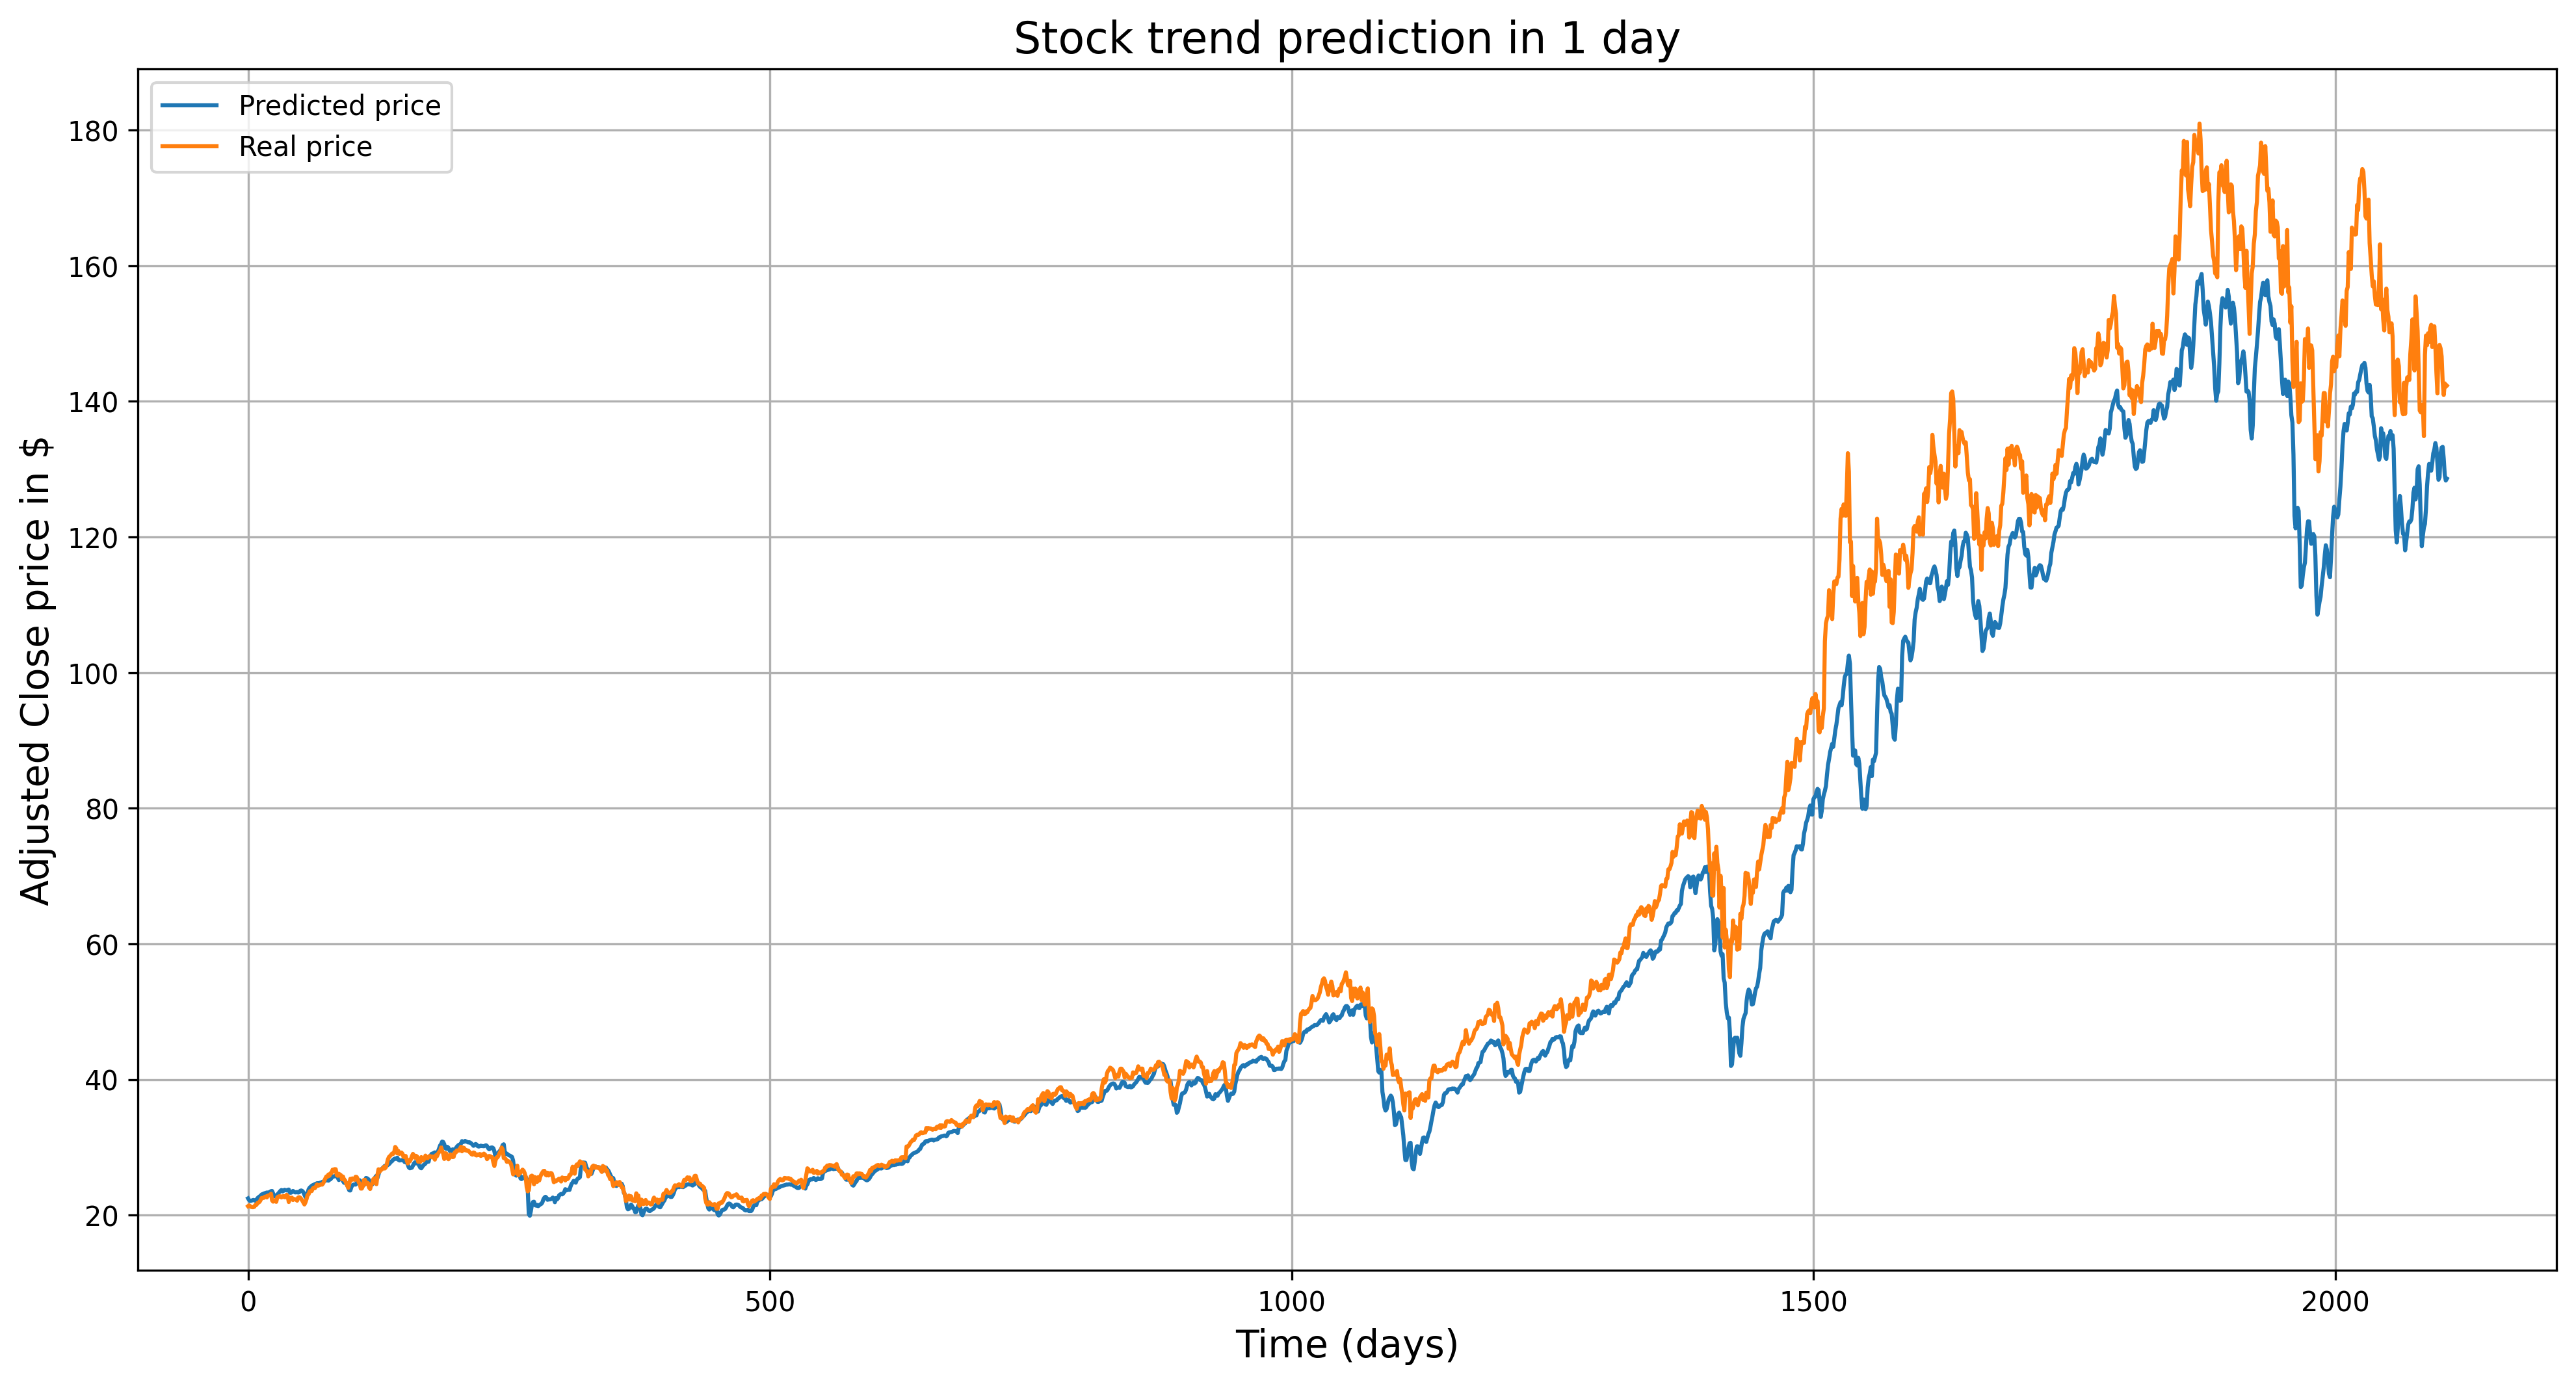


--- Training model for MSFT (multiple features, predicting k=1th day) ---
Number of features used: 4
Shape of training set:  (5896, 50, 4)
Shape of validation set:  (1475, 50, 4)
Shape of test set:  (1843, 50, 4)
Shape of training set labels:  (5896, 1)
Shape of validation set labels:  (1475, 1)
Shape of test set labels:  (1843, 1)

Training model for MSFT...
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - loss: 1.1676 - mse: 1.1676 - val_loss: 0.3711 - val_mse: 0.3711
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.6660 - mse: 0.6660 - val_loss: 0.5311 - val_mse: 0.5311
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - loss: 0.6487 - mse: 0.6487 - val_loss: 0.4357 - val_mse: 0.4357
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.6370 - mse: 0.6370 - val_loss: 0.4934 - val_mse: 0.4934
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.6078 - mse: 0.6078 - val_loss: 0.3931 - val_mse: 0.3931
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss:

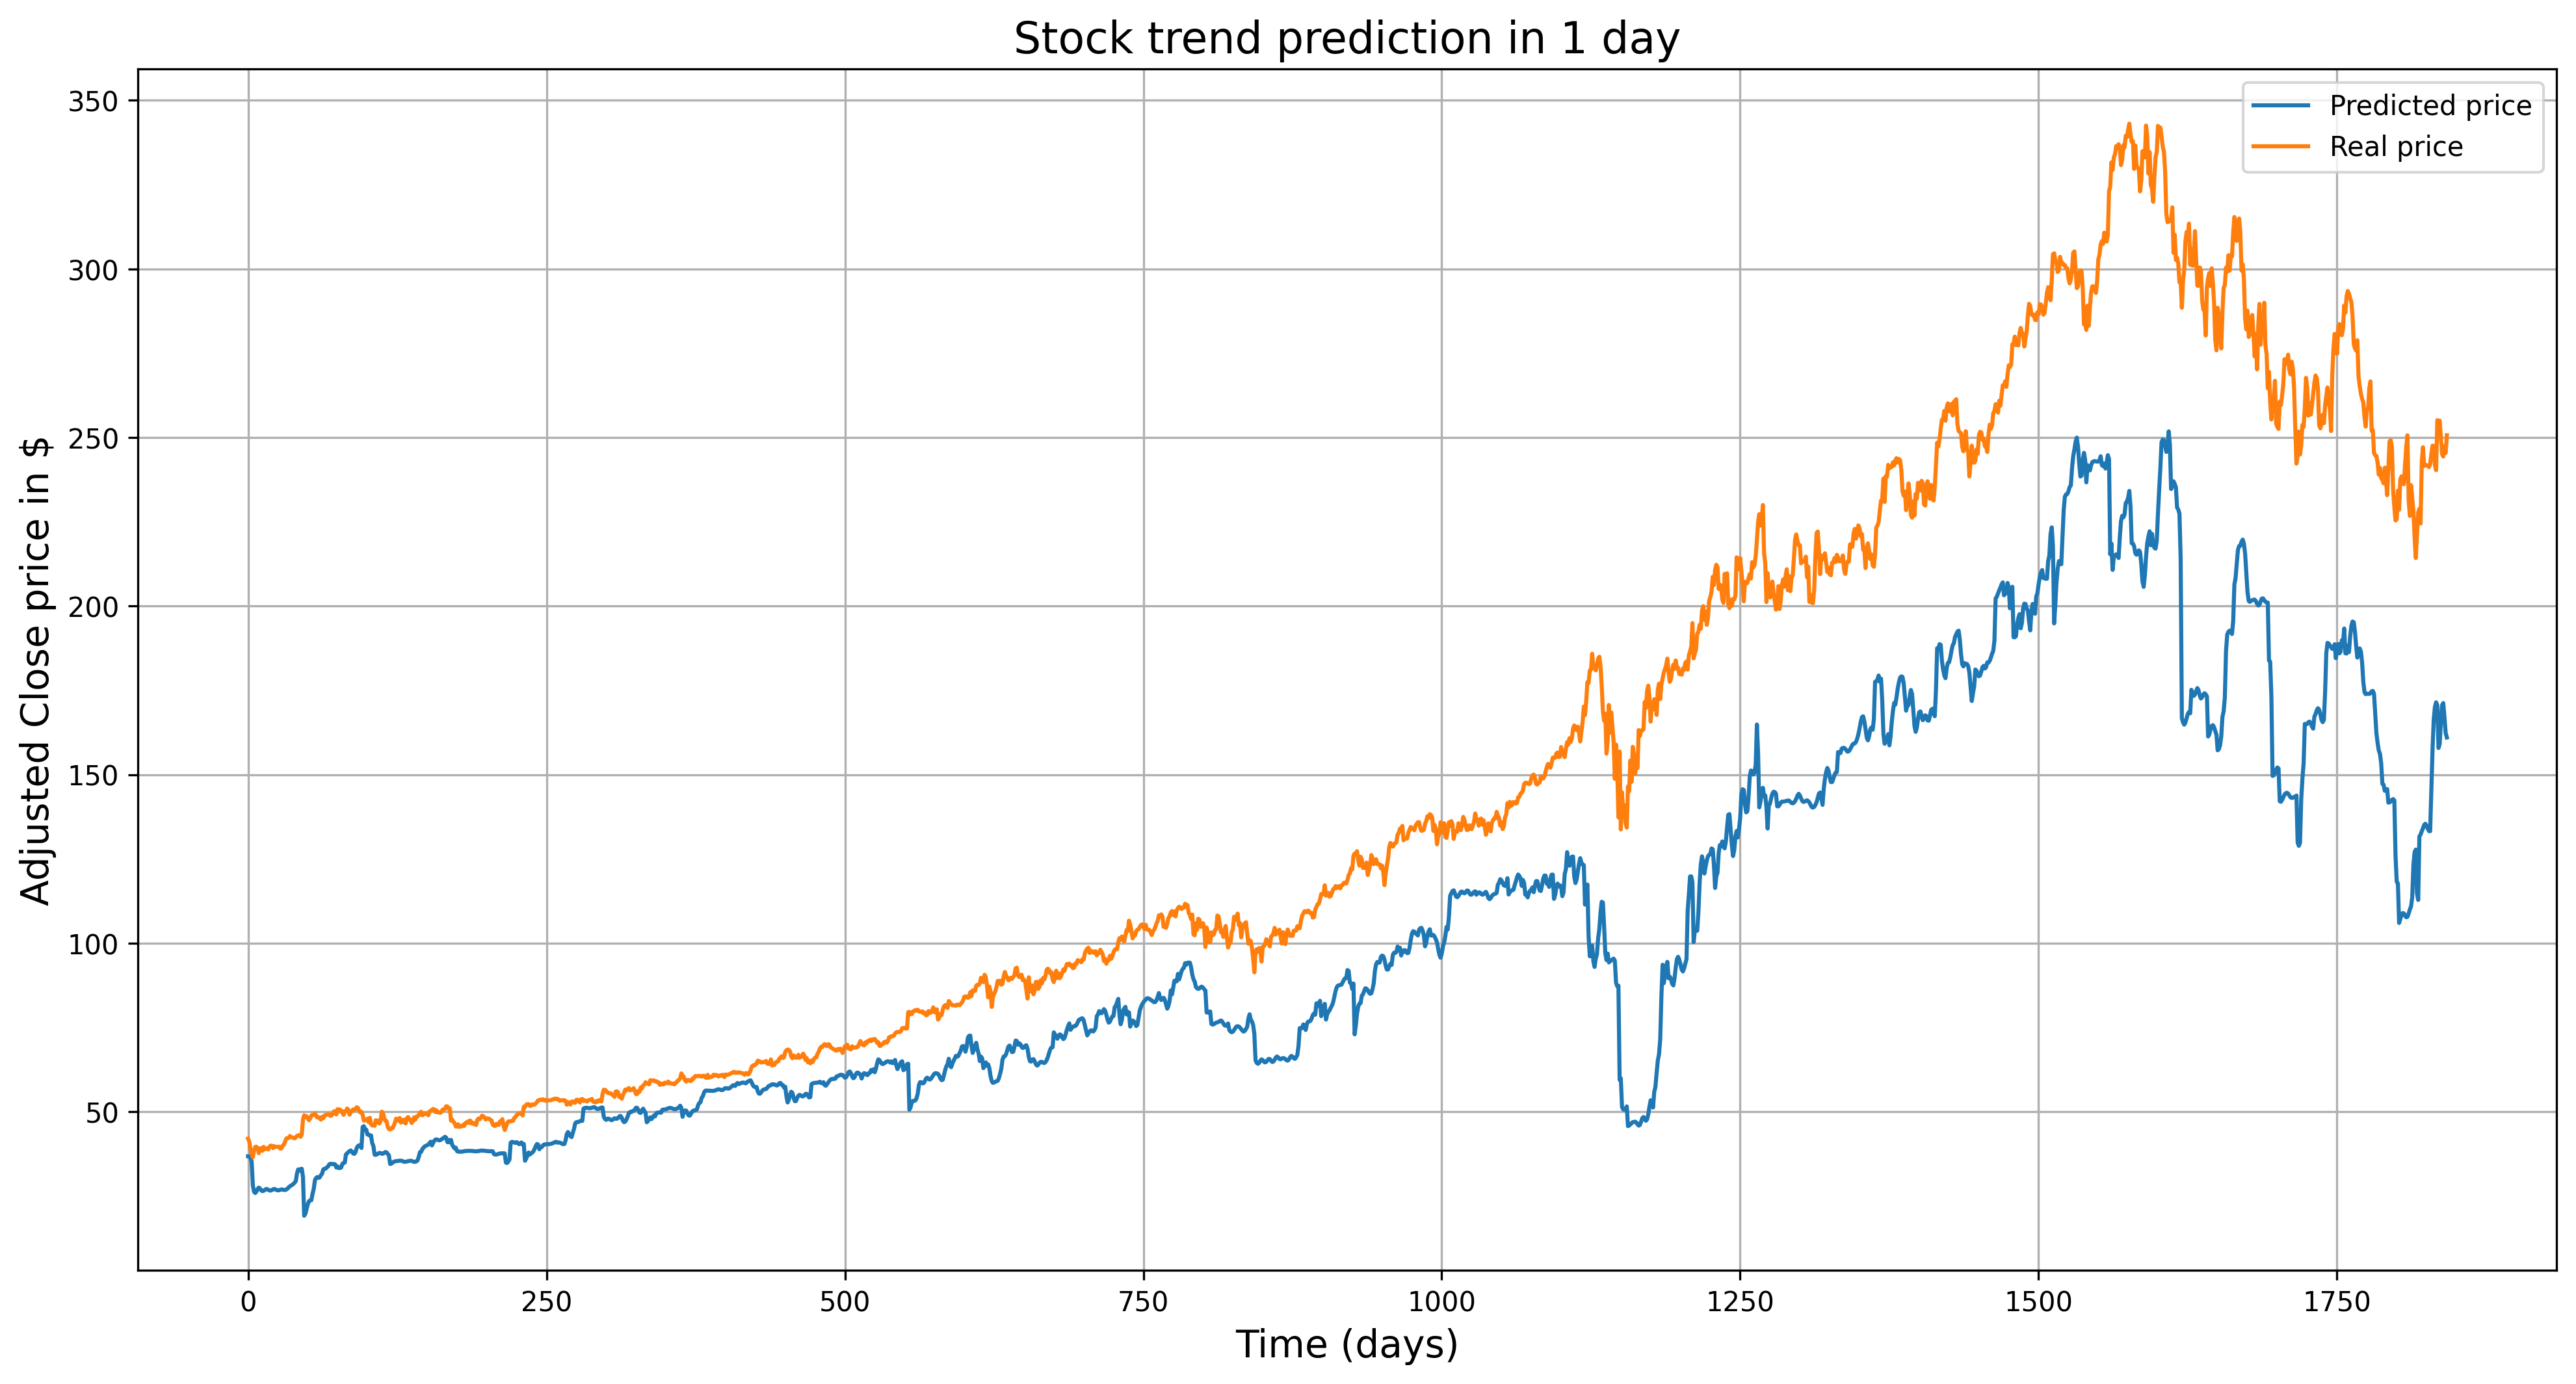


--- Training model for NVDA (multiple features, predicting k=1th day) ---
Number of features used: 4
Shape of training set:  (3816, 50, 4)
Shape of validation set:  (954, 50, 4)
Shape of test set:  (1193, 50, 4)
Shape of training set labels:  (3816, 1)
Shape of validation set labels:  (954, 1)
Shape of test set labels:  (1193, 1)

Training model for NVDA...
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 2.4686 - mse: 2.4686 - val_loss: 0.1058 - val_mse: 0.1058
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0659 - mse: 0.0659 - val_loss: 0.0868 - val_mse: 0.0868
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.0462 - mse: 0.0462 - val_loss: 0.0601 - val_mse: 0.0601
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0476 - mse: 0.0476 - val_loss: 0.0503 - val_mse: 0.0503
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.0386 - mse: 0.0386 - val_loss: 0.0556 - val_mse: 0.0556
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.0372 - mse:

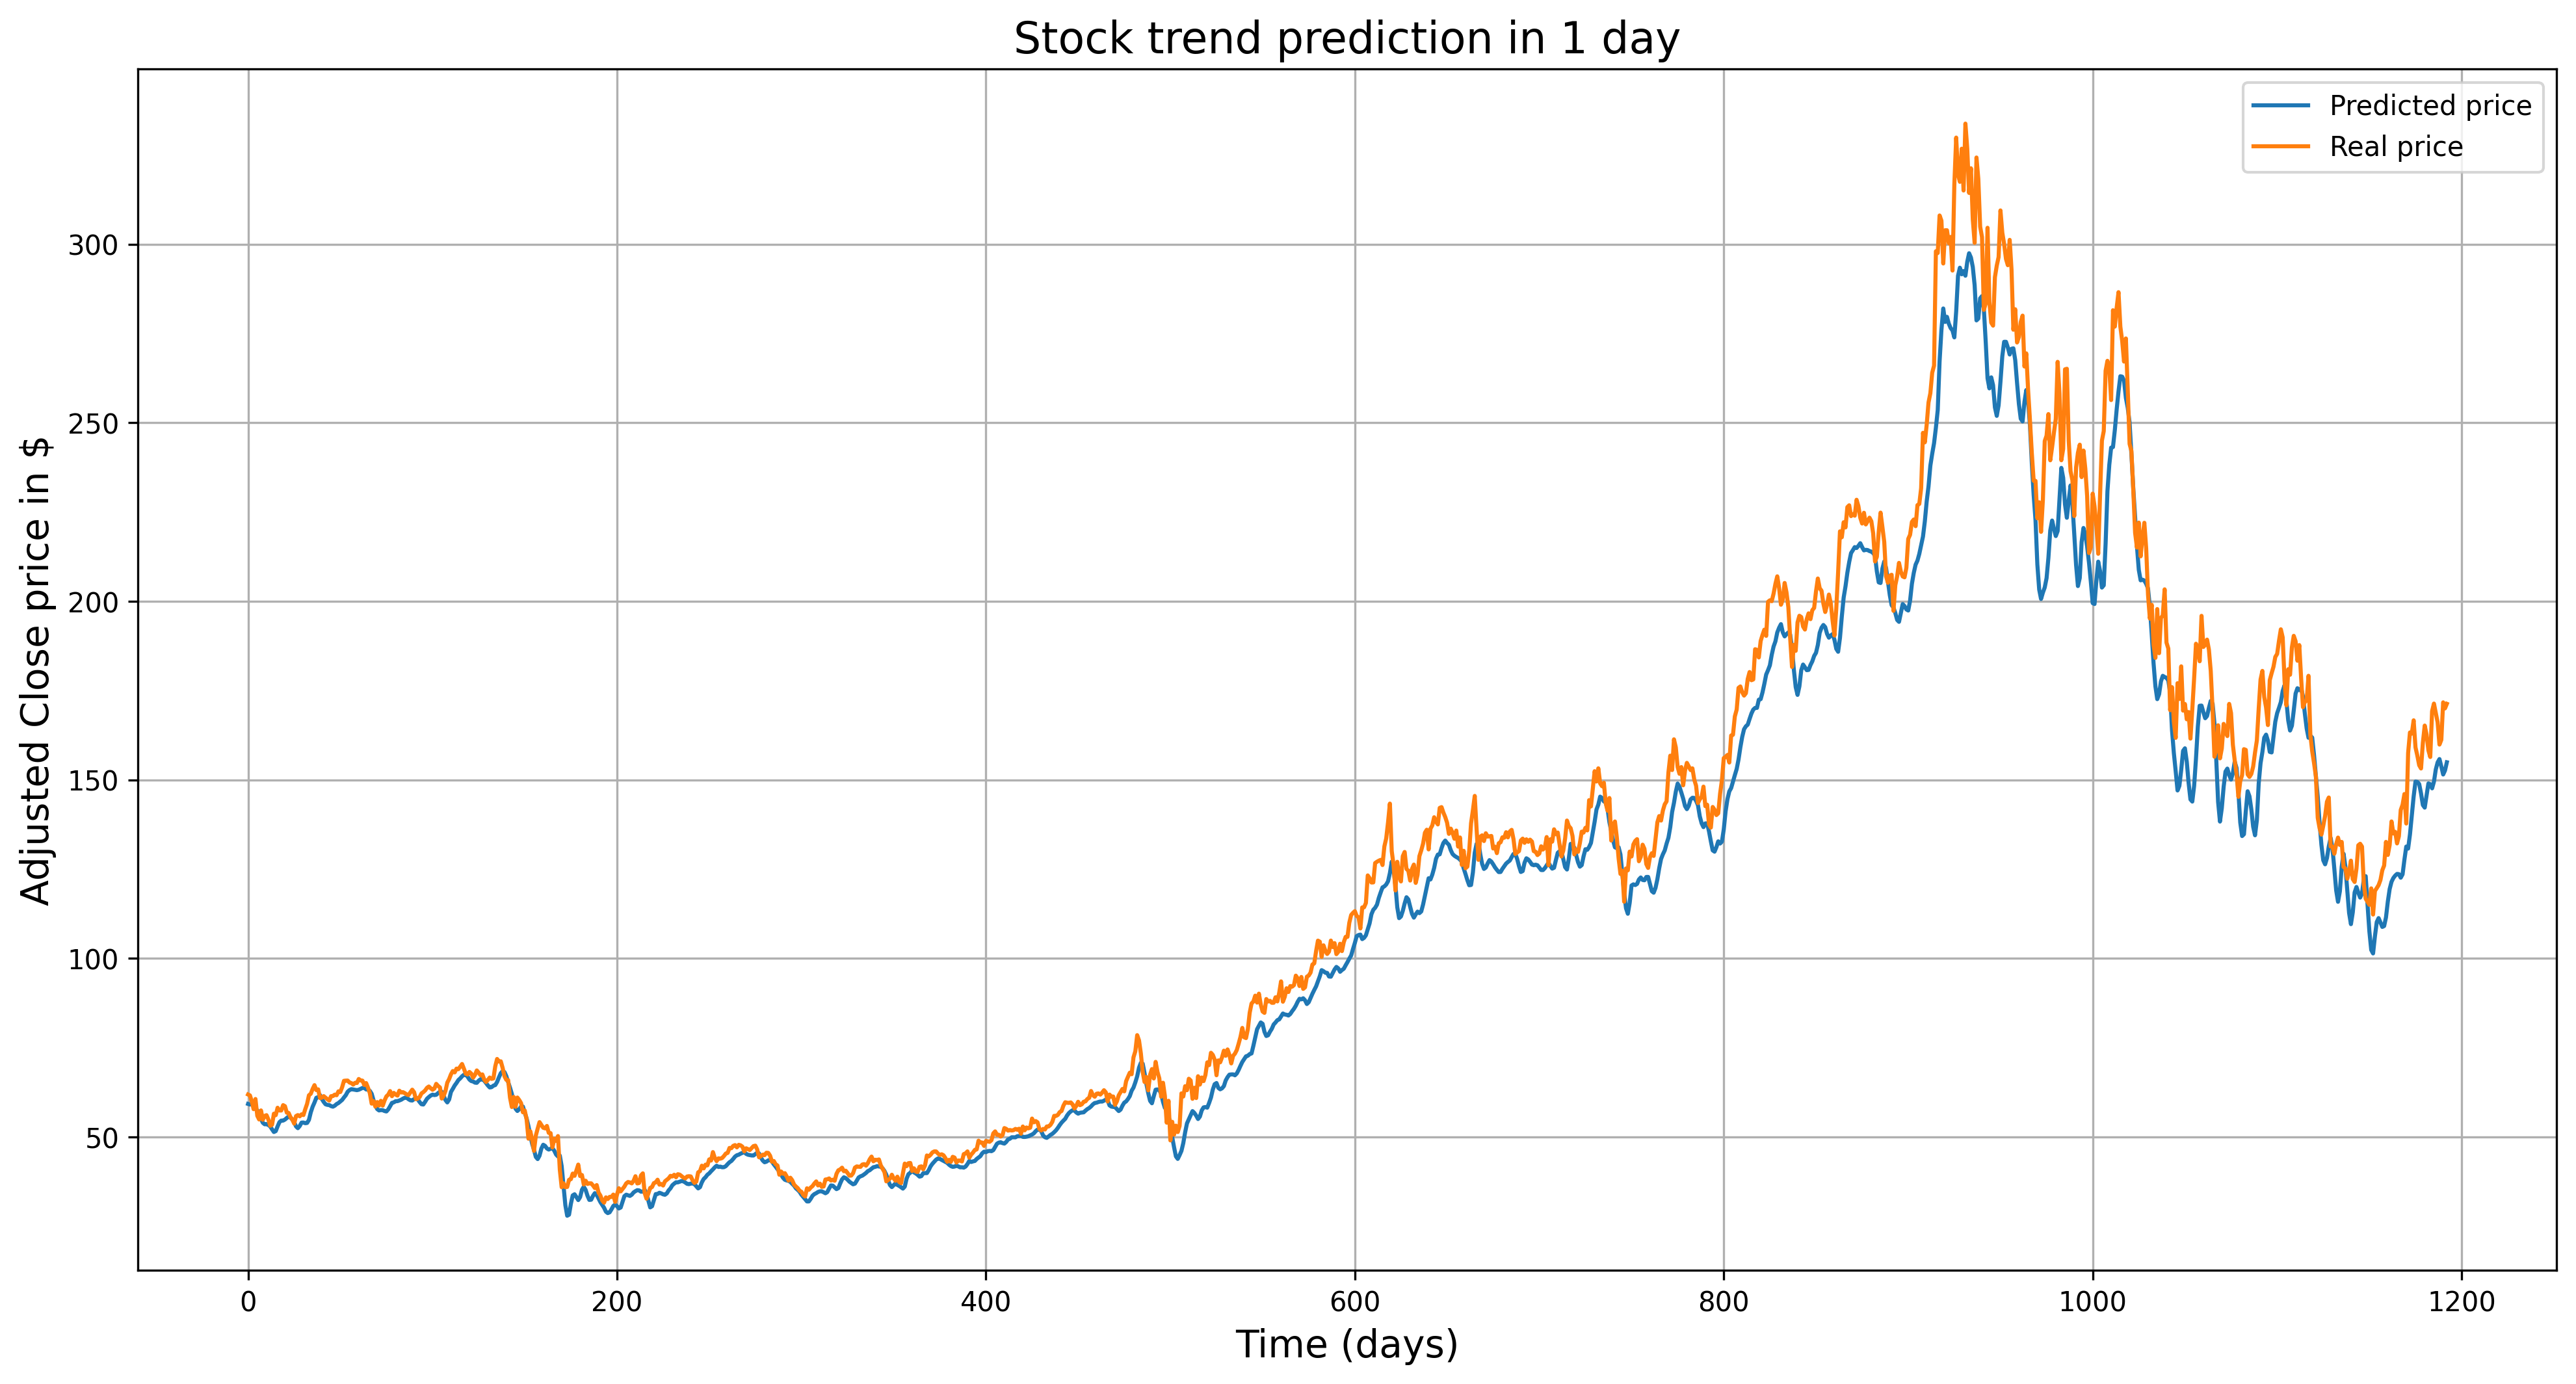

In [23]:
companies = combined_df['Company'].unique()

window_size = 50
feature_columns = ['Open', 'High', 'Low', 'Close']
predicted_label = 'Adjusted Close'
k = 1 # Predicting the next day (1st day after the window)
num_prediction_steps = 1 # We are predicting a single value here

for company in companies:
    print(f"\n--- Training model for {company} (multiple features, predicting k={k}th day) ---")

    # 1. Filter data for the current company
    company_df = combined_df[combined_df['Company'] == company].copy()
    company_df = company_df.reset_index(drop=True)

    # 2. Prepare data samples for the current company (using data_split_label for k-th day prediction)
    X_data, y_data, num_features = data_split_label(company_df, feature_columns, predicted_label, window_size, k)

    # 3. Split into train, validation, and test sets
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_train_val_test_data(X_data, y_data, window_size, num_features, num_prediction_steps)

    # Store original y_test for denormalization visualization
    y_test_original = y_test.copy()

    # 4. Normalize the data using the corrected function
    X_train_norm, y_train_norm, X_val_norm, y_val_norm, X_test_norm, y_test_norm = MinMax_normalize(X_train, y_train, X_val, y_val, X_test, y_test)

    # 5. Build the model with num_prediction_steps
    model = build_model(window_size, num_features, num_prediction_steps)

    # 6. Train the model (verbose=1 to see epoch progress)
    print(f"\nTraining model for {company}...")
    history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=10, batch_size=512, verbose=1)
    print(f"Model for {company} trained.")
    model.save(f'{company}_1st.keras')
    print(f"Last trained model saved as '{company}_1st.keras'")

    # 7. Evaluate and visualize predictions
    y_pred_norm = model.predict(X_test_norm)
    mse = mean_squared_error(y_test_norm, y_pred_norm)
    print(f"MSE on the test set for {company}: {mse}")

    visualize_prediction(y_pred_norm, y_test, predicted_label, k)

    # Clear TensorFlow session to prevent issues with subsequent model builds
    tf.keras.backend.clear_session()

#K-th day


--- Training model for AAPL (single feature, predicting k=7th day) ---
Number of features used: 4
Shape of training set:  (6741, 50, 4)
Shape of validation set:  (1686, 50, 4)
Shape of test set:  (2107, 50, 4)
Shape of training set labels:  (6741, 1)
Shape of validation set labels:  (1686, 1)
Shape of test set labels:  (2107, 1)

Training model for AAPL...
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 0.5965 - mse: 0.5965 - val_loss: 0.1774 - val_mse: 0.1774
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.1537 - mse: 0.1537 - val_loss: 0.1589 - val_mse: 0.1589
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.1284 - mse: 0.1284 - val_loss: 0.1181 - val_mse: 0.1181
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - loss: 0.1194 - mse: 0.1194 - val_loss: 0.1135 - val_mse: 0.1135
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - loss: 0.1168 - mse: 0.1168 - val_loss: 0.1106 - val_mse: 0.1106
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.

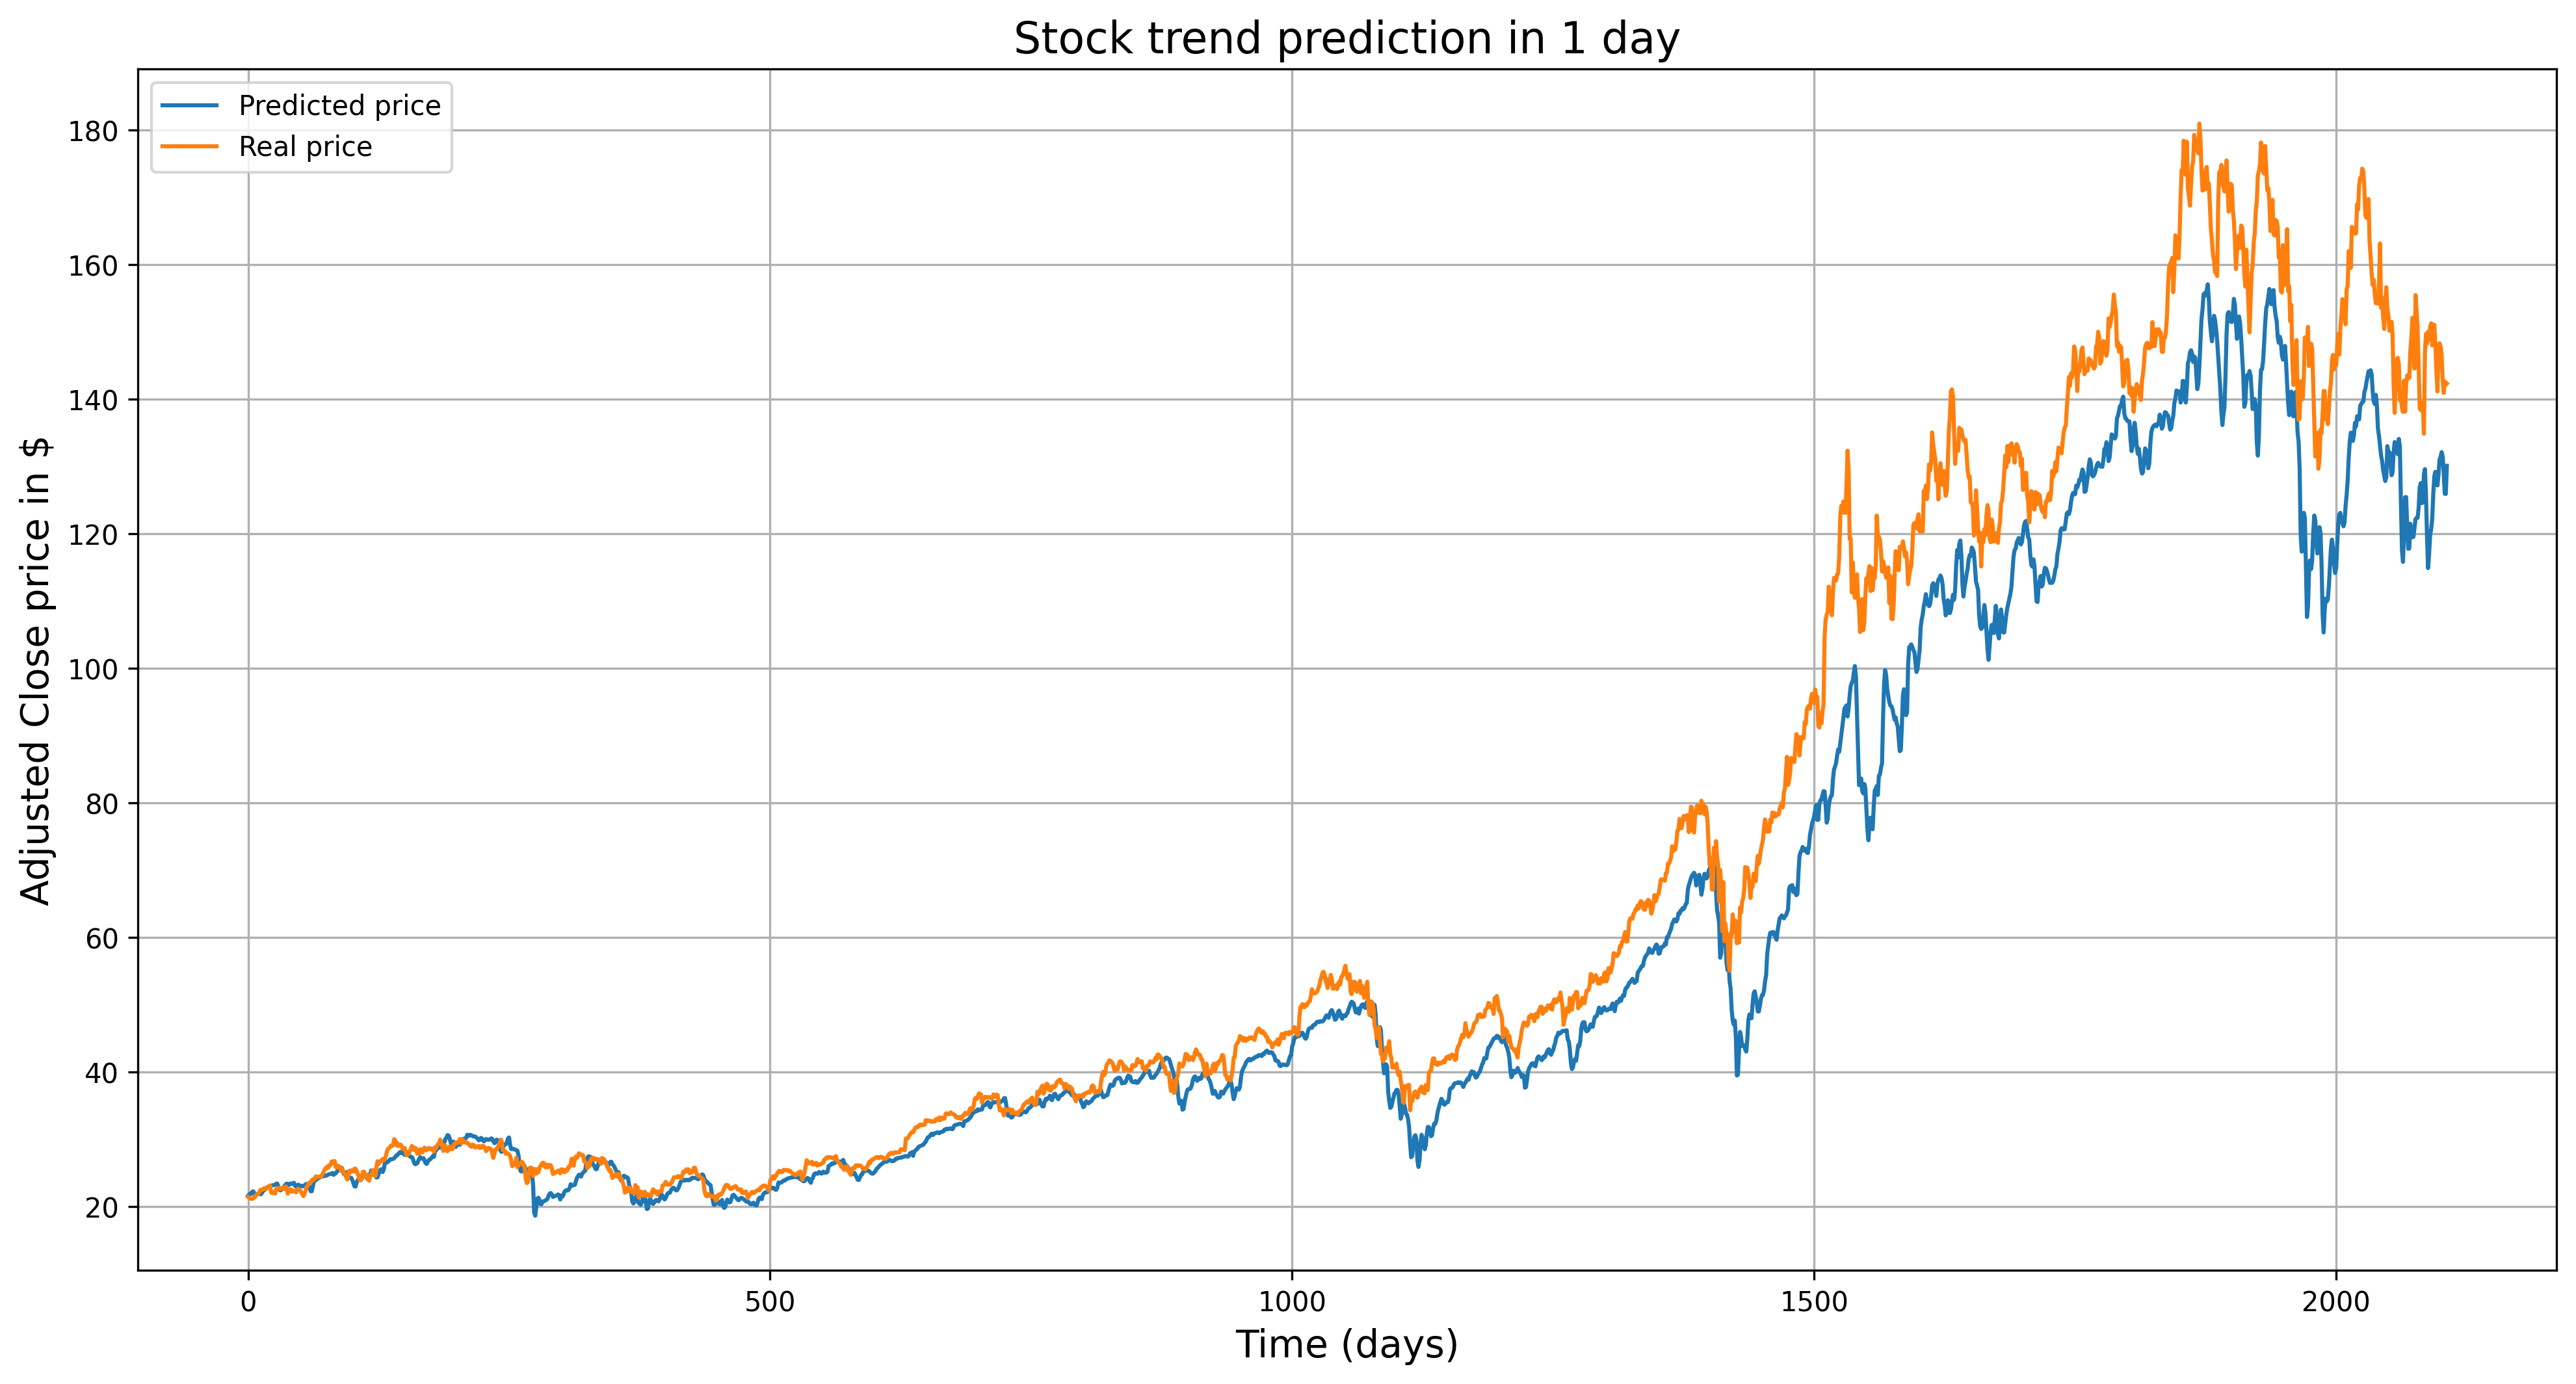


--- Training model for MSFT (single feature, predicting k=7th day) ---
Number of features used: 4
Shape of training set:  (5892, 50, 4)
Shape of validation set:  (1474, 50, 4)
Shape of test set:  (1842, 50, 4)
Shape of training set labels:  (5892, 1)
Shape of validation set labels:  (1474, 1)
Shape of test set labels:  (1842, 1)

Training model for MSFT...
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - loss: 1.6848 - mse: 1.6848 - val_loss: 0.6004 - val_mse: 0.6004
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 0.6935 - mse: 0.6935 - val_loss: 0.4231 - val_mse: 0.4231
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.6424 - mse: 0.6424 - val_loss: 0.3586 - val_mse: 0.3586
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.6335 - mse: 0.6335 - val_loss: 0.4974 - val_mse: 0.4974
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.6104 - mse: 0.6104 - val_loss: 0.5261 - val_mse: 0.5261
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.

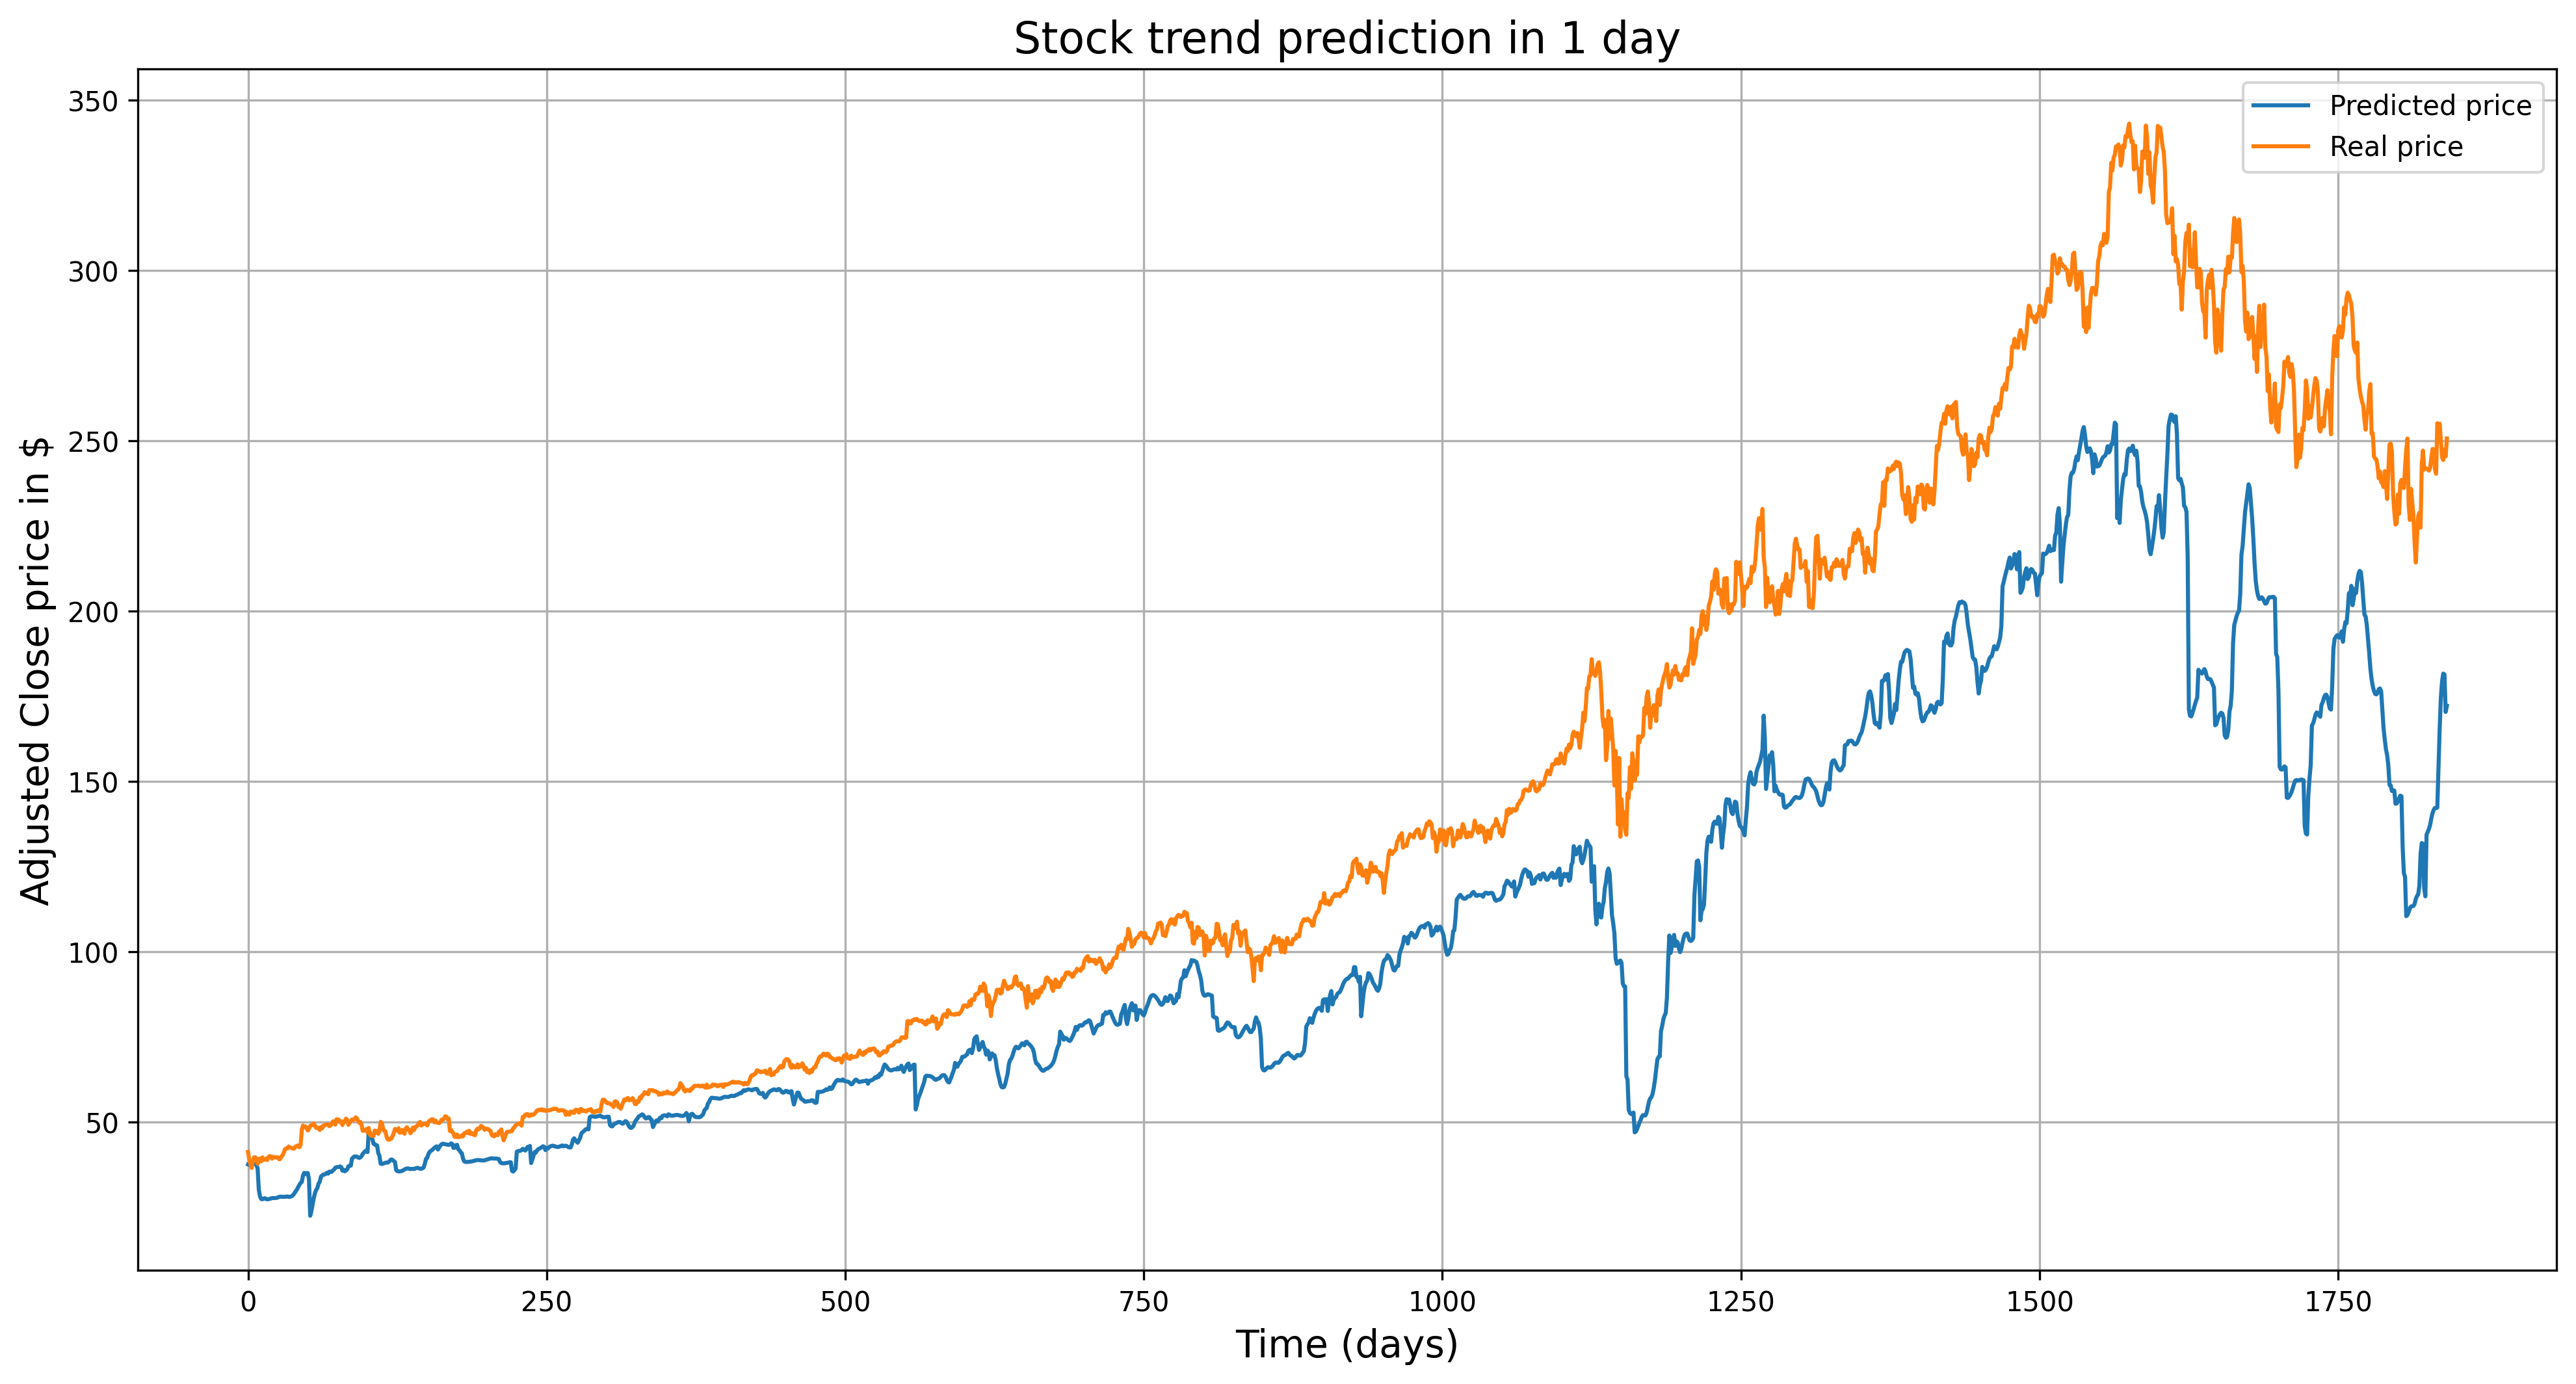


--- Training model for NVDA (single feature, predicting k=7th day) ---
Number of features used: 4
Shape of training set:  (3812, 50, 4)
Shape of validation set:  (953, 50, 4)
Shape of test set:  (1192, 50, 4)
Shape of training set labels:  (3812, 1)
Shape of validation set labels:  (953, 1)
Shape of test set labels:  (1192, 1)

Training model for NVDA...
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 0.6766 - mse: 0.6766 - val_loss: 0.2585 - val_mse: 0.2585
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.1215 - mse: 0.1215 - val_loss: 0.3217 - val_mse: 0.3217
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.2481 - mse: 0.2481 - val_loss: 0.4423 - val_mse: 0.4423
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.2585 - mse: 0.2585 - val_loss: 0.5021 - val_mse: 0.5021
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.2241 - mse: 0.2241 - val_loss: 0.3249 - val_mse: 0.3249
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.1962 - mse: 0.

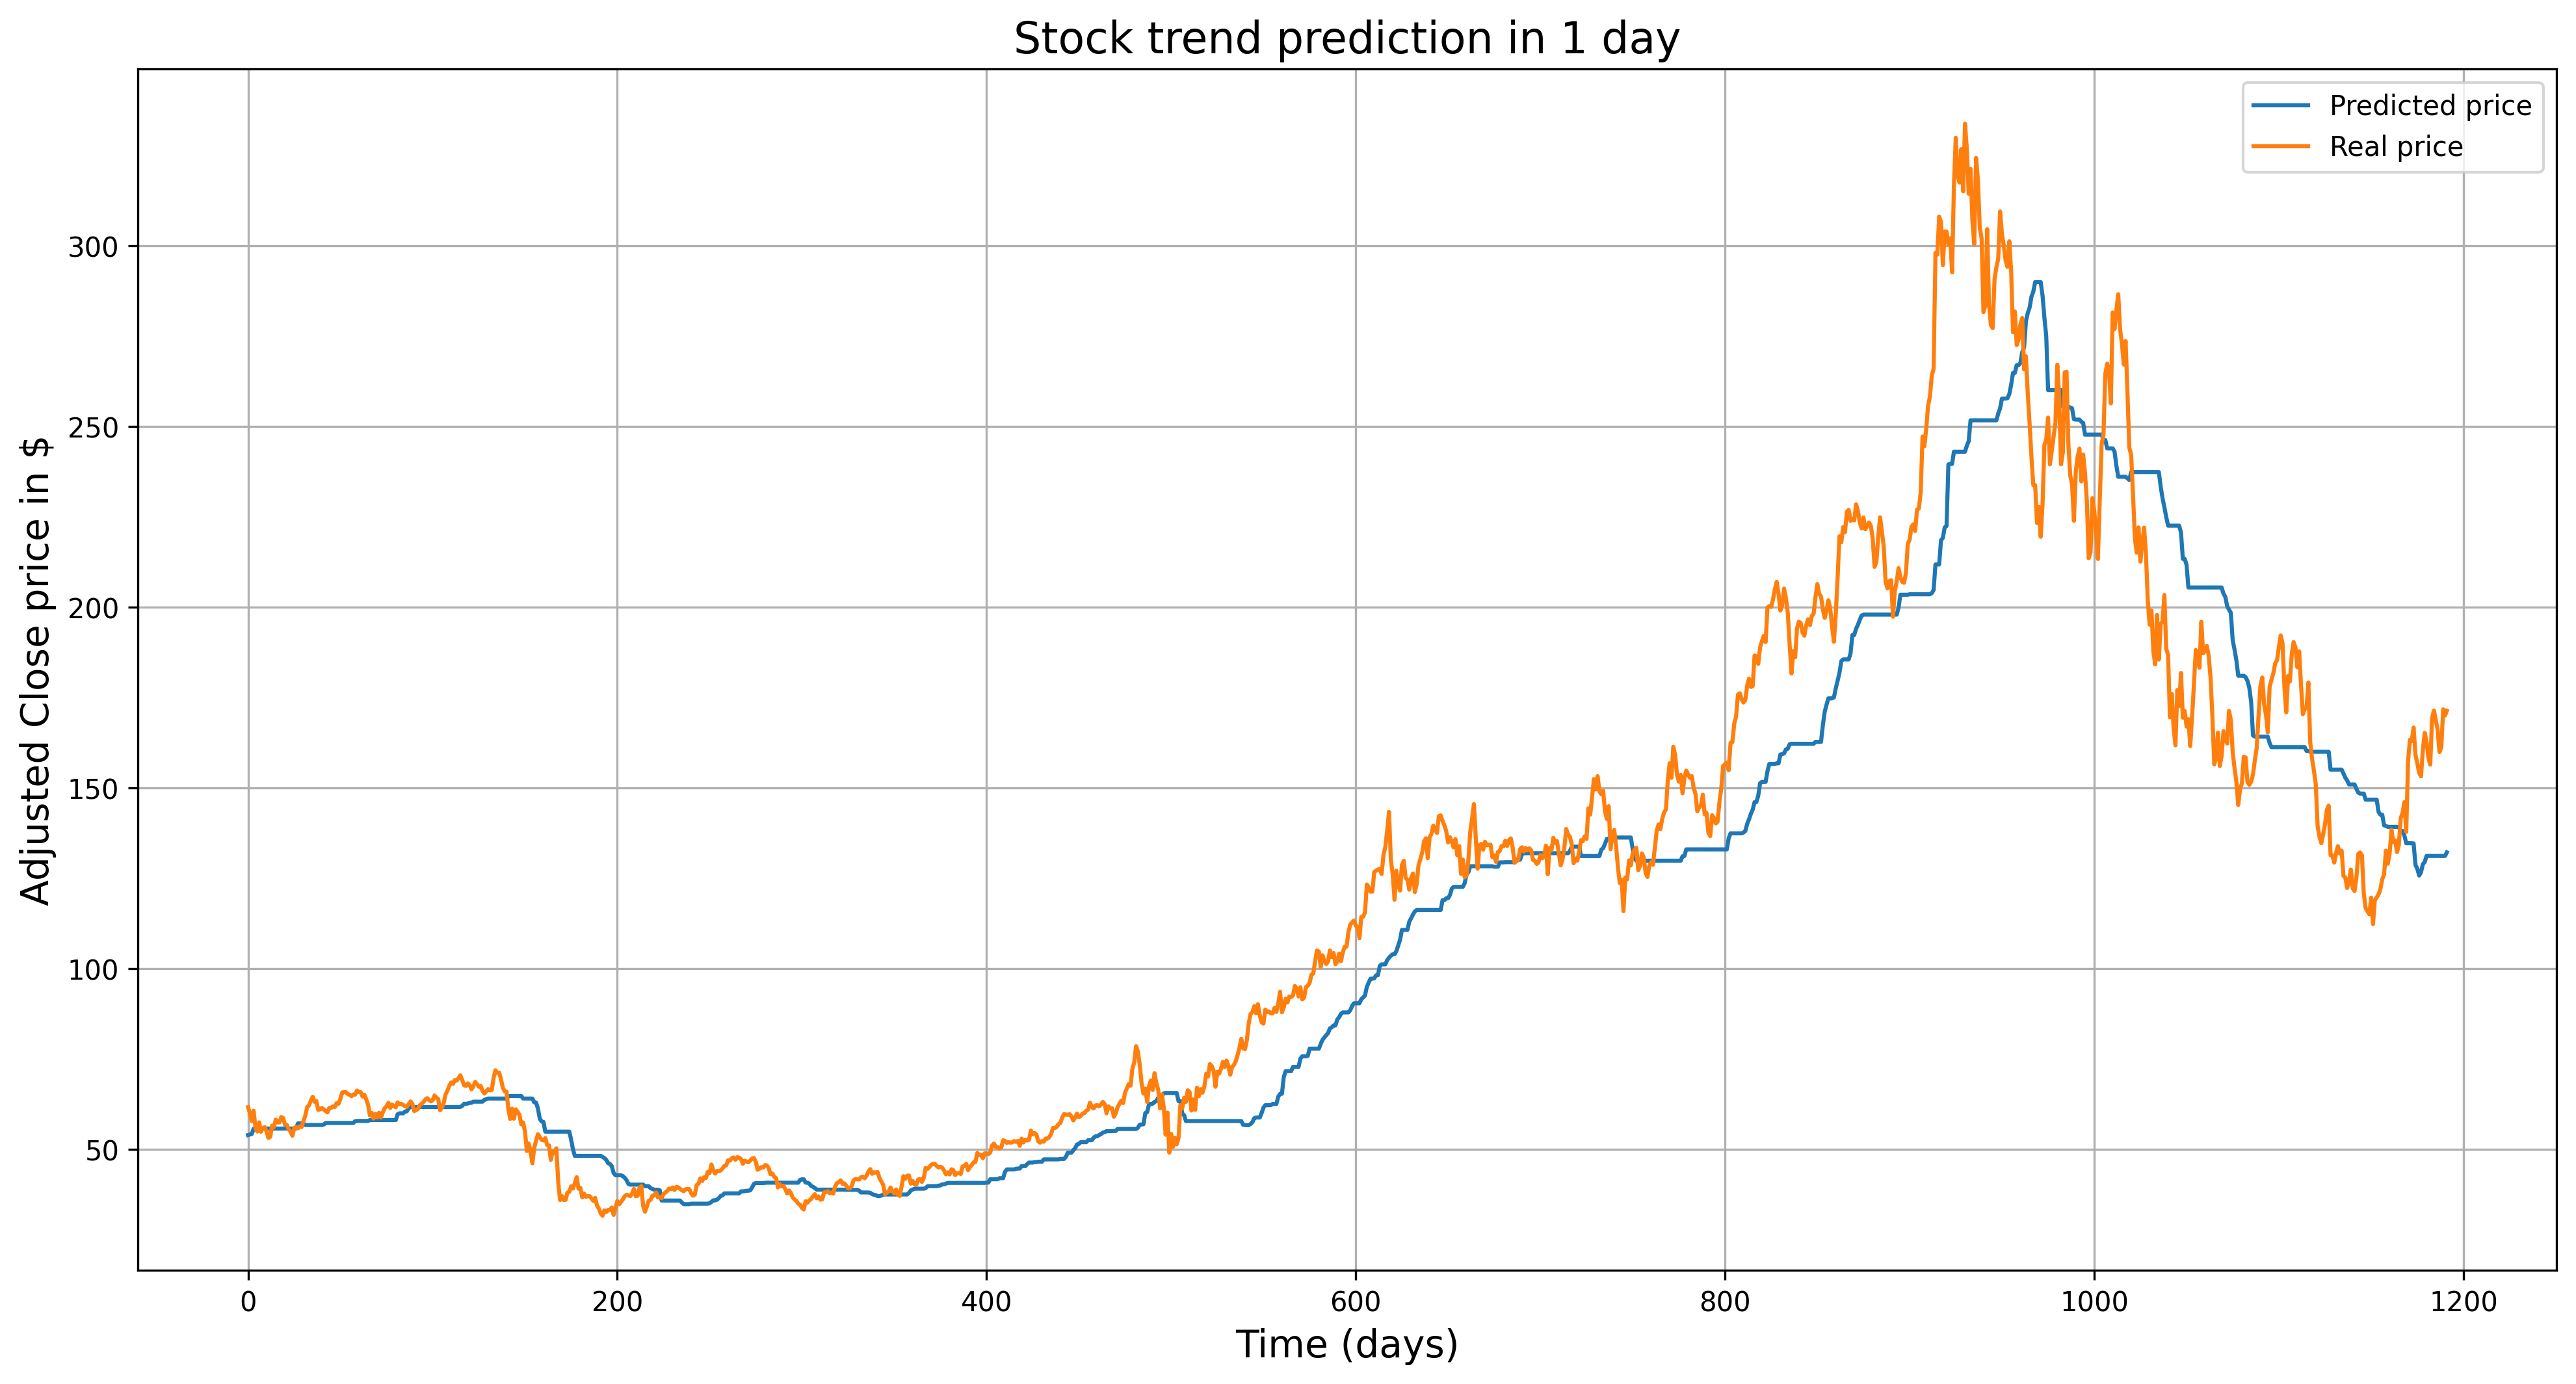

In [27]:
companies = combined_df['Company'].unique()

window_size = 50
feature_columns = ['Open', 'High', 'Low', 'Close']
predicted_label = 'Adjusted Close'
k = 7 # Predicting the 7th day after the window
num_prediction_steps = 1 # We are predicting a single value here

for company in companies:
    print(f"\n--- Training model for {company} (single feature, predicting k={k}th day) ---")

    # 1. Filter data for the current company
    company_df = combined_df[combined_df['Company'] == company].copy()
    company_df = company_df.reset_index(drop=True)

    # 2. Prepare data samples for the current company (using data_split_label for k-th day prediction)
    X_data, y_data, num_features = data_split_label(company_df, feature_columns, predicted_label, window_size, k)

    # 3. Split into train, validation, and test sets
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_train_val_test_data(X_data, y_data, window_size, num_features, num_prediction_steps)

    # Store original y_test for denormalization visualization
    y_test_original = y_test.copy()

    # 4. Normalize the data using the corrected function
    X_train_norm, y_train_norm, X_val_norm, y_val_norm, X_test_norm, y_test_norm = MinMax_normalize(X_train, y_train, X_val, y_val, X_test, y_test)

    # 5. Build the model with num_prediction_steps
    model = build_model(window_size, num_features, num_prediction_steps)

    # 6. Train the model (verbose=1 to see epoch progress)
    print(f"\nTraining model for {company}...")
    history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=10, batch_size=512, verbose=1)
    print(f"Model for {company} trained.")
    model.save(f'{company}_7th.keras')
    print(f"Last trained model saved as '{company}_7th.keras'")

    # 7. Evaluate and visualize predictions
    y_pred_norm = model.predict(X_test_norm)
    mse = mean_squared_error(y_test_norm, y_pred_norm)
    print(f"MSE on the test set for {company}: {mse}")

    visualize_prediction(y_pred_norm, y_test, predicted_label, num_prediction_steps)

    # Clear TensorFlow session to prevent issues with subsequent model builds
    tf.keras.backend.clear_session()

# K days

In [14]:
window_size = 120
feature_columns = ['Open', 'High', 'Low', 'Close']
predicted_label = 'Adjusted Close' # Corrected: Removed leading space
k = 7 # Predicting the next day (1st day after the window)
all_mses_by_day = {day: [] for day in range(k)}
for company in companies:
    print(f"\n--- Training model for {company} (multiple features, predicting k={k}th day) ---")

    # 1. Filter data for the current company
    company_df = combined_df[combined_df['Company'] == company].copy()
    company_df = company_df.reset_index(drop=True)

    # 2. Prepare data samples for the current company (using data_split_label for k-th day prediction)
    X_data, y_data, num_features = data_split_label(company_df, feature_columns, predicted_label, window_size, k, consecutive=True)

    # 3. Split into train, validation, and test sets
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_train_val_test_data(X_data, y_data, window_size, num_features, k)

    # Store original y_test for denormalization visualization
    y_test_original = y_test.copy()

    # 4. Normalize the data using the corrected function
    X_train_norm, y_train_norm, X_val_norm, y_val_norm, X_test_norm, y_test_norm = MinMax_normalize(X_train, y_train, X_val, y_val, X_test, y_test)

    # 5. Build the model with num_prediction_steps
    model = build_model(window_size, num_features, num_outputs=k)

    # 6. Train the model (verbose=1 to see epoch progress)
    print(f"\nTraining model for {company}...")
    history = model.fit(X_train_norm, y_train_norm, validation_data=(X_val_norm, y_val_norm), epochs=15, batch_size=512, verbose=1)
    print(f"Model for {company} trained.")
    model.save(f'{company}_7days.keras')
    print("Last trained model saved as 'model_7days.keras'")

    # 7. Evaluate and visualize predictions
    y_pred_norm = model.predict(X_test_norm)
    mse = mean_squared_error(y_test_norm, y_pred_norm)
    print(f"MSE on the test set for {company}: {mse}")

    # visualize_prediction(y_pred_norm, y_test, predicted_label, k)

    for day_idx in range(k):
        # Extract predictions and actuals for the specific day
        actual_day = y_test_norm[:, day_idx]
        pred_day = y_pred_norm[:, day_idx]

        # Calculate MSE for this day and append to our collection
        day_mse = mean_squared_error(actual_day, pred_day)
        all_mses_by_day[day_idx].append(day_mse)

    print(f"Daily MSEs for {company} recorded.")

    # Clear TensorFlow session to prevent issues with subsequent model builds
    tf.keras.backend.clear_session()


--- Training model for AAPL (multiple features, predicting k=7th day) ---
Number of features used: 4
Shape of training set:  (6696, 120, 4)
Shape of validation set:  (1675, 120, 4)
Shape of test set:  (2093, 120, 4)
Shape of training set labels:  (6696, 7)
Shape of validation set labels:  (1675, 7)
Shape of test set labels:  (2093, 7)

Training model for AAPL...
Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step - loss: 0.3711 - mse: 0.3711 - val_loss: 0.0715 - val_mse: 0.0715
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.1651 - mse: 0.1651 - val_loss: 0.0852 - val_mse: 0.0852
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.1124 - mse: 0.1124 - val_loss: 0.0872 - val_mse: 0.0872
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.0871 - mse: 0.0871 - val_loss: 0.0539 - val_mse: 0.0539
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0729 - mse: 0.0729 - val_loss: 0.0476 - val_mse: 0.0476
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/st

/tmp/ipykernel_7519/2111344128.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = plt.boxplot(plot_data, patch_artist=True,


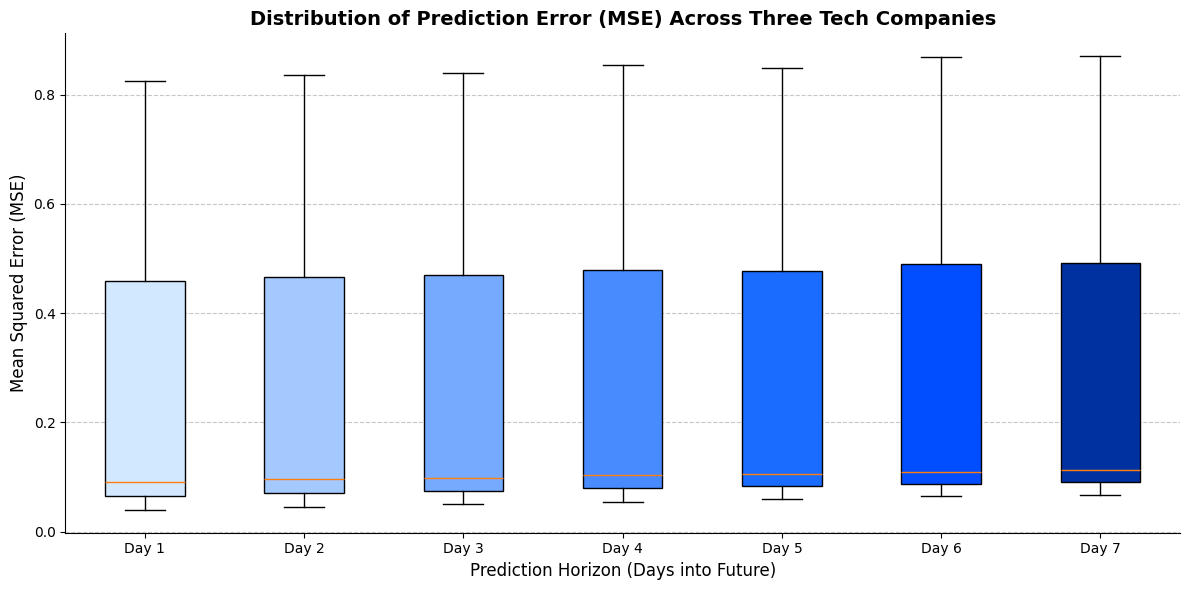

In [15]:
import matplotlib.pyplot as plt

# Prepare the data for the boxplot (a list of 7 lists)
plot_data = [all_mses_by_day[day] for day in range(k)]

plt.figure(figsize=(12, 6))

# Create the boxplot
# patch_artist=True allows us to fill the boxes with color
boxplot = plt.boxplot(plot_data, patch_artist=True,
                      labels=[f"Day {i+1}" for i in range(k)])

# Styling: Use a color gradient to show increasing uncertainty
colors = ['#D1E8FF', '#A3C9FF', '#75AAFF', '#478BFF', '#196CFF', '#004EFF', '#0031A1']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)

# Add titles and labels
plt.title('Distribution of Prediction Error (MSE) Across Three Tech Companies', fontsize=14, fontweight='bold')
plt.xlabel('Prediction Horizon (Days into Future)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Remove top and right spines for a cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()